In [1]:
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

# Parametri

In [2]:
# Indici
I = J = K = range(9)  # righe, colonne, cifre (0 = 1, ..., 8 = 9)

In [3]:
# Griglia iniziale: 0 = cella vuota
grid = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

# Print Functions

In [8]:
def get_solution_grid(model, x, I, J, K):

    # Estrai la soluzione
    solution = [[0]*9 for _ in range(9)]

    if model.status == GRB.OPTIMAL:
        for i in I:
            for j in J:
                for k in K:
                    if x[i,j,k].x > 0.5:
                        solution[i][j] = k + 1
    else:
        print("Nessuna soluzione trovata.")
    
    return solution


def print_sudoku(grid):
    # Visualizza
    plt.figure(figsize=(6,6))
    plt.axis("off")
    for i in range(9):
        for j in range(9):
            plt.text(j + 0.5, 8.5 - i, str(grid[i][j] if grid[i][j] != 0 else ""), ha="center", va="center", fontsize=16)

    for i in range(10):
        lw = 2 if i % 3 == 0 else 0.5
        plt.plot([i, i], [0, 9], color="black", lw=lw)
        plt.plot([0, 9], [i, i], color="black", lw=lw)

    plt.xlim(0, 9)
    plt.ylim(0, 9)
    plt.title("Sudoku")
    plt.show()

    return


# Model

## Problema del Sudoku

### Obiettivo
Riempire una griglia $( 9 \times 9 )$ con i numeri da 1 a 9, in modo che:

- Ogni riga contenga ciascun numero una sola volta
- Ogni colonna contenga ciascun numero una sola volta
- Ogni regione $( 3 \times 3 )$ contenga ciascun numero una sola volta

---

### Input


Sia ( $\mathcal{I} = \mathcal{J} = \mathcal{K} = \{1, \dots, 9\}$ ) dove: \\

$\mathcal{I}$: indici delle righe  \
$\mathcal{J}$: indici delle colonne  \
$\mathcal{K}$: numeri da collocare  
 


Definiamo le variabili binarie:

$$ 
x_{i,j,k} =
\begin{cases} 
1 & \text{se nella cella } (i,j) \text{ si trova il numero } k \\
0 & \text{altrimenti}
\end{cases}
\quad \forall i,j,k \in \{1,\dots,9\}
$$

---

### Funzione obiettivo

Il Sudoku è un **problema di fattibilità**: non c'è nulla da ottimizzare, si cerca **una soluzione ammissibile**.

---

### Vincoli

$$
\begin{align}
% && \min_{\boldsymbol{x} \, \in \, \{0, 1\}} \sum_{i,j,k \, \in \, \mathcal{I}, \mathcal{J}, \mathcal{K}}^{K} x_{i,j,k} \\
&& \min_{\boldsymbol{x} \, \in \, \{0, 1\}} 0 \\

&& \sum_{k=1}^{9} x_{i,j,k}  \, &= 1 && \forall i \in \mathcal{I},\; \forall j \in \mathcal{J} \quad \text{(una cifra per cella)} \\
&& \sum_{j=1}^{9} x_{i,j,k}  \, &= 1 && \forall i \in \mathcal{I},\; \forall k \in \mathcal{K} \quad \text{(una cifra per riga)} \\
&& \sum_{i=1}^{9} x_{i,j,k}  \, &= 1 && \forall j \in \mathcal{J},\; \forall k \in \mathcal{K} \quad \text{(una cifra per colonna)} \\
&& \sum_{i=3r+1}^{3r+3} \sum_{j=3s+1}^{3s+3} x_{i,j,k} \, &= 1 && \forall r,s \in \{0,1,2\},\; \forall k \in \mathcal{K} \quad \text{(una cifra per regione)} \\
&& x_{i,j,k} \, &= 1 && \text{se } k \text{ è dato inizialmente in } (i,j) \quad \text{(celle precompilate)}
\end{align}
$$

---

### Note


- È un classico esempio di **Programmazione Lineare Intera Binaria**.
- Viene modellato come un problema di **soddisfacibilità vincolata** (feasibility).

In [5]:
def solve_sudoku(grid):
    model = Model("Sudoku")
    model.setParam("OutputFlag", 0)

    

    # Variabili binarie
    x = model.addVars(I, J, K, vtype=GRB.BINARY, name="x")

    # Vincoli: una cifra per cella
    for i in I:
        for j in J:
            model.addConstr(quicksum(x[i,j,k] for k in K) == 1)

    # Vincoli: ogni cifra una volta per riga
    for i in I:
        for k in K:
            model.addConstr(quicksum(x[i,j,k] for j in J) == 1)

    # Vincoli: ogni cifra una volta per colonna
    for j in J:
        for k in K:
            model.addConstr(quicksum(x[i,j,k] for i in I) == 1)

    # Vincoli: ogni cifra una volta per blocco 3x3
    for block_i in range(3):
        for block_j in range(3):
            for k in K:
                model.addConstr(quicksum(
                    x[i,j,k]
                    for i in range(3*block_i, 3*block_i+3)
                    for j in range(3*block_j, 3*block_j+3)
                ) == 1)

    # Vincoli: celle precompilate
    for i in I:
        for j in J:
            if grid[i][j] > 0:
                k = grid[i][j] - 1
                model.addConstr(x[i,j,k] == 1)

    # Obiettivo: solo fattibilità
    model.setObjective(0, GRB.MINIMIZE)
    model.optimize()

    return model, x


# Example

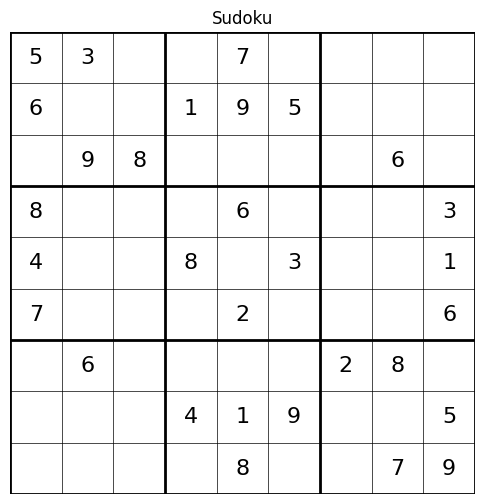

In [9]:
print_sudoku(grid)

Set parameter Username
Set parameter LicenseID to value 2782407
Academic license - for non-commercial use only - expires 2027-02-24


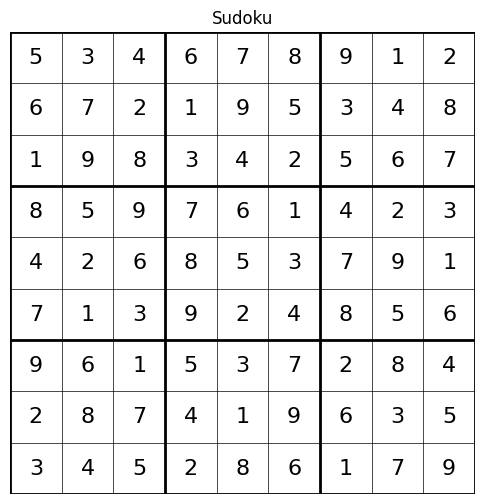

In [7]:
model, x = solve_sudoku(grid)
solution = get_solution_grid(model, x, I, J, K)
print_sudoku(solution)